# [Global Temporal Split] Feature-Enhanced NCF (Staged Ablations)

**Model:** Neural Collaborative Filtering with side features  
**Purpose:** Test whether adding content and contextual signals improves over the ID-only NCF baseline.

**Staged ablations:**
- Stage 1: ID embeddings + `item_semantic_embedding_static` (SBERT 384-dim)
- Stage 2: Stage 1 + structured item metadata + item temporal popularity features
- Stage 3: Stage 2 + user-item matching signals + user history features

**Input files:** `App2_train.pkl`, `App2_val.pkl`, `App2_test.pkl`  
**Evaluation (Val and Test Sets):** Same 5k sampled users as ID-only NCF (global_temporal_val_eval_sample_users.csv &  global_temporal_test_eval_sample_5k_users.csv)

# Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR  = '/content/drive/My Drive/BT4222Project/'

SEED = 4222
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = 10

print(f"Device : {DEVICE}")
print(f"K      : {K}")

Mounted at /content/drive
Device : cuda
K      : 10


# Load Splits

We load the global temporal train, validation, and test interaction files. The validation and test files are the **warm-start** subsets, meaning cold-start users and items have already been removed before this notebook.

For each split:
- `user_id` and `book_id` are cast to string
- `event_time` is parsed as datetime
- rows missing any core field (`user_id`, `book_id`, or `event_time`) are dropped
- rows are sorted by `user_id` and `event_time`



In [ ]:
train_df = pd.read_pickle(DATA_DIR + "App2_train.pkl")
val_df   = pd.read_pickle(DATA_DIR + "App2_val_ws.pkl")
test_df  = pd.read_pickle(DATA_DIR + "App2_test_ws.pkl")

for df in [train_df, val_df, test_df]:
    df["user_id"]    = df["user_id"].astype(str)
    df["book_id"]    = df["book_id"].astype(str)
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    # Drop rows missing core keys
    df.dropna(subset=["user_id", "book_id", "event_time"], inplace=True)

    df.sort_values(["user_id", "event_time"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users")
print(f"\nColumns: {train_df.columns.tolist()}")

Train : 7,454,809 rows  |  410,740 users
Val   : 612,745 rows  |  85,098 users
Test  : 259,317 rows  |  50,011 users

Columns: ['user_id', 'book_id', 'review_id', 'event_time', 'title', 'description', 'description_truncated', 'has_meaningful_description', 'publication_year', 'num_pages', 'language_code_collapsed', 'format_collapsed', 'is_ebook', 'authors_standardized', 'main_author_id', 'author_interactions_count_before_t', 'top_shelf_tags', 'item_text_for_embedding', 'item_semantic_embedding_static', 'item_num_pages', 'user_page_preference_before_t', 'num_pages_preference_gap', 'user_hist_interaction_count_before_t', 'days_since_user_last_interaction', 'book_interactions_count_before_t', 'days_since_book_last_interaction', 'user_author_interaction_share_before_t', 'user_hist_author_diversity_before_t', 'user_profile_embedding_similarity']


In [ ]:
train_users = set(train_df["user_id"].unique())
train_items = set(train_df["book_id"].unique())

assert set(val_df["user_id"].unique()).issubset(train_users)
assert set(test_df["user_id"].unique()).issubset(train_users)
assert set(val_df["book_id"].unique()).issubset(train_items)
assert set(test_df["book_id"].unique()).issubset(train_items)

print("Warm-start checks passed.")

Warm-start checks passed.


# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

user_enc.fit(train_df["user_id"])
item_enc.fit(train_df["book_id"])

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

# Train-set density
N_train = len(train_df)
density_train = N_train / (num_users * num_items)

print(f"Train users (U)       : {num_users:,}")
print(f"Train items (I)       : {num_items:,}")
print(f"Train interactions    : {N_train:,}")
print(f"Train density         : {density_train * 100:.6f}%")

# Overall split sizes for reference
N_all = len(train_df) + len(val_df) + len(test_df)
print(f"Total rows (all splits): {N_all:,}")

def encode_df(df, user_enc, item_enc):
    user_mask = df["user_id"].isin(user_enc.classes_)
    item_mask = df["book_id"].isin(item_enc.classes_)

    d = df.loc[user_mask & item_mask].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df, user_enc, item_enc)
val_enc   = encode_df(val_df, user_enc, item_enc)
test_enc  = encode_df(test_df, user_enc, item_enc)

print(f"\nEncoded train : {len(train_enc):,} rows")
print(f"Encoded val   : {len(val_enc):,} rows")
print(f"Encoded test  : {len(test_enc):,} rows")

print("\nRows dropped during encoding:")
print(f"Val dropped   : {len(val_df) - len(val_enc):,}")
print(f"Test dropped  : {len(test_df) - len(test_enc):,}")

assert len(train_enc) == len(train_df), "Train should not lose rows during encoding"
assert len(val_enc) == len(val_df), "Some val rows were unexpectedly dropped during encoding"
assert len(test_enc) == len(test_df), "Some test rows were unexpectedly dropped during encoding"

print("\nEncoding coverage checks passed.")

Train users (U)       : 410,740
Train items (I)       : 114,452
Train interactions    : 7,454,809
Train density         : 0.015858%
Total rows (all splits): 8,326,871

Encoded train : 7,454,809 rows
Encoded val   : 612,745 rows
Encoded test  : 259,317 rows

Rows dropped during encoding:
Val dropped   : 0
Test dropped  : 0

Encoding coverage checks passed.


# Categorical Encoding for Side Features

This step converts text categories into integer IDs so they can be used by the model.

We create mappings for:
- `format_collapsed`
- `language_code_collapsed`
- `main_author_id`

The mappings are built using the **training set only**, then reused for validation and test. This avoids data leakage.

If a value is missing, or if a category appears in validation/test but was not seen in training, it is mapped to `"unknown"`.

In [ ]:
# =========================================================
# Fit side-feature categorical encoders on TRAIN ONLY
# and transform train / val / test using train mappings
# =========================================================

def make_safe_mapping(series):
    vals = series.fillna("unknown").astype(str).unique().tolist()
    if "unknown" not in vals:
        vals.append("unknown")
    vals = sorted(vals)
    return {v: i for i, v in enumerate(vals)}

# Fit on TRAIN ONLY
format2idx = make_safe_mapping(train_df["format_collapsed"])
lang2idx   = make_safe_mapping(train_df["language_code_collapsed"])
author2idx = make_safe_mapping(train_df["main_author_id"])

num_formats = len(format2idx)
num_langs   = len(lang2idx)
num_authors = len(author2idx)

print(f"Formats  : {num_formats}")
print(f"Languages: {num_langs}")
print(f"Authors  : {num_authors}")

def encode_categoricals(df):
    d = df.copy()

    d["format_idx"] = (
        d["format_collapsed"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: format2idx.get(x, format2idx["unknown"]))
    )

    d["lang_idx"] = (
        d["language_code_collapsed"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: lang2idx.get(x, lang2idx["unknown"]))
    )

    d["author_idx"] = (
        d["main_author_id"]
        .fillna("unknown")
        .astype(str)
        .map(lambda x: author2idx.get(x, author2idx["unknown"]))
    )

    return d

# Apply same train-fitted mappings to all splits
train_enc = encode_categoricals(train_enc)
val_enc   = encode_categoricals(val_enc)
test_enc  = encode_categoricals(test_enc)

print("Categorical encoding done.")

Formats  : 11
Languages: 76
Authors  : 23545
Categorical encoding done.


# Numerical Feature Scaling

Numerical side features are standardised using `StandardScaler` so they are on a comparable scale before being fed into the model.

The scaler is **fit on the training set only**, then the same transformation is applied to validation and test. This avoids data leakage from future splits.

Any missing values are filled with `0` before scaling. Only numerical columns that are present in the encoded dataframes are scaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

# All numerical side features across all stages
NUMERICAL_COLS = [
    # Stage 2 — item metadata
    "num_pages", "publication_year",
    # Stage 2 — item temporal popularity
    "book_interactions_count_before_t",
    "days_since_book_last_interaction",
    "author_interactions_count_before_t",
    # Stage 3 — user-item matching
    "num_pages_preference_gap",
    "user_profile_embedding_similarity",
    # Stage 3 — user history
    "user_hist_interaction_count_before_t",
    "user_hist_author_diversity_before_t",
    # user_author_interaction_share_before_t is already 0-1 but scale anyway
    "user_author_interaction_share_before_t",
]

# Only scale columns that exist in the dataframe
NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in train_enc.columns]
print(f"Scaling {len(NUMERICAL_COLS)} numerical columns")

scaler = StandardScaler()
train_enc[NUMERICAL_COLS] = scaler.fit_transform(
    train_enc[NUMERICAL_COLS].fillna(0))
val_enc[NUMERICAL_COLS]   = scaler.transform(
    val_enc[NUMERICAL_COLS].fillna(0))
test_enc[NUMERICAL_COLS]  = scaler.transform(
    test_enc[NUMERICAL_COLS].fillna(0))

print("Scaling done.")

Scaling 11 numerical columns
Scaling done.


# Negative Sampling (Top-1000 Popular Books)

Same negative sampling strategy as the ID-only NCF baseline.

- Observed training interactions are treated as positive samples.
- For each user, negative samples are drawn at an approximate **1:1 ratio** from the **top-1000 most popular books in the training set**.
- Books the user has already interacted with in the **training split** are excluded from that user’s negative pool.

In [ ]:
from time import perf_counter
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

start_t = perf_counter()

# =========================================================
# 1. Top-1000 most popular books from TRAIN ONLY
# =========================================================
top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)

item_class_set = set(item_enc.classes_)
top_1000_books = [b for b in top_1000_books if b in item_class_set]
top_1000_idx = item_enc.transform(top_1000_books).astype(np.int32)

print(f"Top-1000 pool size: {len(top_1000_idx)}")

# =========================================================
# 2. TRAIN-ONLY user history
# =========================================================
user_train_history_idx = (
    train_enc.groupby("user_id")["item_idx"]
    .apply(lambda x: set(x.astype(np.int32)))
    .to_dict()
)

# =========================================================
# 3. Positive rows: keep only IDs + label
# =========================================================
pos = train_enc[["user_idx", "item_idx"]].copy()
pos["user_idx"] = pos["user_idx"].astype(np.int32)
pos["item_idx"] = pos["item_idx"].astype(np.int32)
pos["label"] = np.int8(1)

# =========================================================
# 4. Precompute helpers
# =========================================================
user_pos_counts = train_enc.groupby("user_id", sort=False).size()
user_to_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .astype(np.int32)
    .to_dict()
)

rng = np.random.default_rng(SEED)
neg_user_chunks = []
neg_item_chunks = []

for user_id, n_pos in tqdm(
    user_pos_counts.items(),
    total=len(user_pos_counts),
    desc="Negative sampling",
    unit="user"
):
    seen_idx = user_train_history_idx.get(user_id, set())

    if seen_idx:
        mask = ~np.isin(top_1000_idx, list(seen_idx))
        pool_idx = top_1000_idx[mask]
    else:
        pool_idx = top_1000_idx

    n_neg = min(int(n_pos), int(pool_idx.size))
    if n_neg == 0:
        continue

    sampled_idx = rng.choice(pool_idx, size=n_neg, replace=False)
    neg_user_chunks.append(np.full(n_neg, user_to_idx[user_id], dtype=np.int32))
    neg_item_chunks.append(sampled_idx.astype(np.int32))

# =========================================================
# 5. Negative rows: keep only IDs + label
# =========================================================
if neg_user_chunks:
    neg = pd.DataFrame({
        "user_idx": np.concatenate(neg_user_chunks),
        "item_idx": np.concatenate(neg_item_chunks),
        "label": np.int8(0),
    })
else:
    neg = pd.DataFrame(columns=["user_idx", "item_idx", "label"])

# =========================================================
# 6. Combine and shuffle
# =========================================================
train_with_neg = pd.concat([pos, neg], ignore_index=True)
train_with_neg = train_with_neg.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nTrain positives        : {len(pos):,}")
print(f"Train negatives        : {len(neg):,}")
print(f"Train rows (with negs) : {len(train_with_neg):,}")
print("\nLabel counts:")
print(train_with_neg['label'].value_counts())
print(f"\nNegative sampling time: {perf_counter() - start_t:.1f}s")

Top-1000 pool size: 1000


Negative sampling:   0%|          | 0/410740 [00:00<?, ?user/s]


Train positives        : 7,454,809
Train negatives        : 7,104,278
Train rows (with negs) : 14,559,087

Label counts:
label
1    7454809
0    7104278
Name: count, dtype: int64

Negative sampling time: 22.6s


# Build Item Feature Matrices

Item-side features are organised into lookup matrices indexed by `item_idx`:
- **item categorical matrix** for encoded categorical features
- **item numerical matrix** for scaled numerical features
- **item SBERT matrix** for static semantic embeddings, if available

These matrices allow the model to retrieve item features efficiently during training.

In [ ]:
import numpy as np
import pandas as pd

# ---------- item categorical features ----------
item_cat_cols = [c for c in ["format_idx", "lang_idx", "author_idx"] if c in train_enc.columns]

if item_cat_cols:
    item_cat_df = (
        train_enc[["item_idx"] + item_cat_cols]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_cat_matrix = item_cat_df.to_numpy(dtype=np.int64)
else:
    item_cat_matrix = None

# ---------- item numerical features ----------
item_num_cols = [
    c for c in [
        "num_pages",
        "publication_year",
        "book_interactions_count_before_t",
        "days_since_book_last_interaction",
        "author_interactions_count_before_t",
    ]
    if c in train_enc.columns
]

if item_num_cols:
    item_num_df = (
        train_enc[["item_idx"] + item_num_cols]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_num_matrix = item_num_df.to_numpy(dtype=np.float32)
else:
    item_num_matrix = None

# ---------- item SBERT embedding ----------
if "item_semantic_embedding_static" in train_enc.columns:
    item_sbert_df = (
        train_enc[["item_idx", "item_semantic_embedding_static"]]
        .drop_duplicates("item_idx")
        .sort_values("item_idx")
        .set_index("item_idx")
    )
    item_sbert_matrix = np.vstack(
        item_sbert_df["item_semantic_embedding_static"].values
    ).astype(np.float32)
else:
    item_sbert_matrix = None

print("Item cat matrix shape  :", None if item_cat_matrix is None else item_cat_matrix.shape)
print("Item num matrix shape  :", None if item_num_matrix is None else item_num_matrix.shape)
print("Item SBERT matrix shape:", None if item_sbert_matrix is None else item_sbert_matrix.shape)

Item cat matrix shape  : (114452, 3)
Item num matrix shape  : (114452, 5)
Item SBERT matrix shape: (114452, 384)


In [ ]:
if item_cat_matrix is not None:
    assert item_cat_matrix.shape[0] == num_items

if item_num_matrix is not None:
    assert item_num_matrix.shape[0] == num_items

if item_sbert_matrix is not None:
    assert item_sbert_matrix.shape[0] == num_items
    assert item_sbert_matrix.shape[1] == 384

print("Lookup matrix checks passed.")

Lookup matrix checks passed.


# Dataset and DataLoader

`FeatureNCFDataset` prepares the training data for the feature-enhanced NCF models. Each row contains only `user_idx`, `item_idx`, and `label`, while item-side features are retrieved on demand from precomputed lookup matrices using `item_idx`.

Two training dataloaders are created:
- **Stage 1:** uses item semantic embeddings only
- **Stage 2:** uses item categorical features, numerical features, and semantic embeddings

The fixed sampled validation and test user lists are then reloaded so that evaluation remains consistent across reruns and NCF model variants.

Again, for each sampled user, only valid warm-start items present in the training vocabulary are kept for ranking evaluation.

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset

class FeatureNCFDataset(Dataset):
    """
    df should contain only:
      - user_idx
      - item_idx
      - label

    Item-side features are fetched on demand from lookup matrices
    using item_idx.
    """
    def __init__(
        self,
        df,
        item_cat_matrix=None,
        item_num_matrix=None,
        item_sbert_matrix=None,
        label_col="label",
    ):
        self.users = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df[label_col].values, dtype=torch.float32)

        self.item_cat_matrix = None
        self.item_num_matrix = None
        self.item_sbert_matrix = None

        if item_cat_matrix is not None:
            self.item_cat_matrix = torch.tensor(item_cat_matrix, dtype=torch.long)

        if item_num_matrix is not None:
            self.item_num_matrix = torch.tensor(item_num_matrix, dtype=torch.float32)

        if item_sbert_matrix is not None:
            self.item_sbert_matrix = torch.tensor(item_sbert_matrix, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        user = self.users[idx]
        item = self.items[idx]

        batch = {
            "user": user,
            "item": item,
            "label": self.labels[idx],
        }

        # item is a scalar tensor; use its integer value for lookup
        item_i = int(item.item())

        if self.item_cat_matrix is not None:
            batch["cat_feats"] = self.item_cat_matrix[item_i]

        if self.item_num_matrix is not None:
            batch["num_feats"] = self.item_num_matrix[item_i]

        if self.item_sbert_matrix is not None:
            batch["emb_feats"] = self.item_sbert_matrix[item_i]

        return batch

print("FeatureNCFDataset defined.")

FeatureNCFDataset defined.


Stage 1 - only SBERT item embeddings

In [ ]:
from torch.utils.data import DataLoader

train_dataset_s1 = FeatureNCFDataset(
    train_with_neg,
    item_sbert_matrix=item_sbert_matrix,
    label_col="label",
)

train_loader_s1 = DataLoader(
    train_dataset_s1,
    batch_size=512,
    shuffle=True,
    pin_memory=True,
)

print(f"Stage 1 train batches: {len(train_loader_s1)}")

Stage 1 train batches: 28436


Stage 2 - categorical + numerical + SBERT item features

In [ ]:
train_dataset_s2 = FeatureNCFDataset(
    train_with_neg,
    item_cat_matrix=item_cat_matrix,
    item_num_matrix=item_num_matrix,
    item_sbert_matrix=item_sbert_matrix,
    label_col="label",
)

train_loader_s2 = DataLoader(
    train_dataset_s2,
    batch_size=512,
    shuffle=True,
    pin_memory=True,
)

print(f"Stage 2 train batches: {len(train_loader_s2)}")

Stage 2 train batches: 28436


Build Validation Users from val_df  and Test Users from test_df for final evaluation

In [ ]:
val_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_val_eval_sample_users.csv"
).iloc[:, 0].astype(str).tolist()

test_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_test_eval_sample_5k_users.csv"
).iloc[:, 0].astype(str).tolist()

print(f"Loaded {len(val_sample_user_ids):,} val sampled users")
print(f"Loaded {len(test_sample_user_ids):,} test sampled users")

user_train_seen = train_df.groupby("user_id")["book_id"].apply(set).to_dict()

val_true_items_per_user = val_df.groupby("user_id")["book_id"].apply(list).to_dict()
test_true_items_per_user = test_df.groupby("user_id")["book_id"].apply(list).to_dict()

user_to_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .to_dict()
)

item_to_idx = (
    train_enc.drop_duplicates("book_id")
    .set_index("book_id")["item_idx"]
    .to_dict()
)

val_eval_users = [
    (uid, [b for b in val_true_items_per_user[uid] if b in item_to_idx])
    for uid in val_sample_user_ids
    if uid in val_true_items_per_user and uid in user_to_idx
]
val_eval_users = [(uid, books) for uid, books in val_eval_users if books]

test_eval_users = [
    (uid, [b for b in test_true_items_per_user[uid] if b in item_to_idx])
    for uid in test_sample_user_ids
    if uid in test_true_items_per_user and uid in user_to_idx
]
test_eval_users = [(uid, books) for uid, books in test_eval_users if books]

print(f"Validation on {len(val_eval_users):,} users")
print(f"Test evaluation on {len(test_eval_users):,} users")

Loaded 5,000 val sampled users
Loaded 5,000 test sampled users
Validation on 5,000 users
Test evaluation on 5,000 users


## 7. Feature-Enhanced NCF Model

Two-branch architecture:
- **Collaborative branch:** user_id + book_id embeddings (same as ID-only NCF)
- **Side-feature branch:** processes item/user features separately

Both branches are concatenated and passed through a shared MLP for prediction.

The model is configurable — pass only the features relevant to each stage.

In [ ]:
class FeatureEnhancedNCF(nn.Module):
    def __init__(self,
                 num_users, num_items,
                 embedding_dim=32,
                 # Categorical side feature sizes (Stage 2+)
                 num_formats=0, num_langs=0, num_authors=0,
                 cat_emb_dim=8,
                 # Numerical feature count (Stage 2+)
                 num_numerical=0,
                 # Static embedding dim (Stage 1+)
                 static_emb_dim=0,
                 dropout=0.5):
        super().__init__()

        # Collaborative branch
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Side-feature branch
        self.use_static_emb = static_emb_dim > 0
        self.use_cats       = (num_formats > 0 and num_langs > 0 and num_authors > 0)
        self.use_numerical  = num_numerical > 0

        if self.use_static_emb:
            # Project 384-dim SBERT down to embedding_dim
            self.static_proj = nn.Sequential(
                nn.Linear(static_emb_dim, embedding_dim),
                nn.ReLU()
            )

        if self.use_cats:
            # Category indices already run from 0 to N-1, so do not add +1
            # and do not use padding_idx=0 because 0 is a real category.
            self.format_emb = nn.Embedding(num_formats, cat_emb_dim)
            self.lang_emb   = nn.Embedding(num_langs,   cat_emb_dim)
            self.author_emb = nn.Embedding(num_authors, cat_emb_dim)

        # MLP input size
        cf_dim      = 2 * embedding_dim
        side_dim    = 0
        if self.use_static_emb: side_dim += embedding_dim
        if self.use_cats:       side_dim += 3 * cat_emb_dim
        if self.use_numerical:  side_dim += num_numerical

        mlp_input_dim = cf_dim + side_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, user, item, emb_feats=None, cat_feats=None, num_feats=None):
        # Collaborative branch
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)

        # Side-feature branch
        side_parts = []
        if self.use_static_emb and emb_feats is not None:
            side_parts.append(self.static_proj(emb_feats))
        if self.use_cats and cat_feats is not None:
            fmt_e    = self.format_emb(cat_feats[:, 0])
            lang_e   = self.lang_emb(cat_feats[:, 1])
            author_e = self.author_emb(cat_feats[:, 2])
            side_parts.extend([fmt_e, lang_e, author_e])
        if self.use_numerical and num_feats is not None:
            side_parts.append(num_feats)

        if side_parts:
            x = torch.cat([x] + side_parts, dim=1)

        return self.mlp(x).squeeze(1)

print("FeatureEnhancedNCF defined.")

FeatureEnhancedNCF defined.


# Evaluation Metrics

HitRate@K, MAP@K, nDCG@K







In [ ]:
def hit_rate_at_k(all_preds_rank, all_targets_rank, k=10):
    hits = 0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]
        if target_idx in top_k:
            hits += 1

    return hits / n if n > 0 else 0.0


def map_at_k(all_preds_rank, all_targets_rank, k=10):
    total_ap = 0.0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]

        if target_idx in top_k:
            rank_pos = np.where(top_k == target_idx)[0][0] + 1  # 1-based rank
            total_ap += 1.0 / rank_pos

    return total_ap / n if n > 0 else 0.0


def ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=10):
    total_ndcg = 0.0
    n = len(all_targets_rank)

    for scores, target_idx in zip(all_preds_rank, all_targets_rank):
        top_k = np.argsort(scores)[-k:][::-1]

        if target_idx in top_k:
            rank_pos = np.where(top_k == target_idx)[0][0] + 1  # 1-based rank
            total_ndcg += 1.0 / np.log2(rank_pos + 1)

    return total_ndcg / n if n > 0 else 0.0


print("Ranking metric functions defined.")

Ranking metric functions defined.


## Ranking Evaluation Function

This function evaluates a feature-enhanced NCF model on the sampled warm-start validation or test users using a sampled ranking task.

For each evaluation user:
- one true positive book is used as the target item
- negative books are sampled from the candidate pool after excluding books already interacted with in the training set and the user’s true future items
- the model ranks the target item against the sampled negatives and computes **HR@K**, **MAP@K / MRR@K**, and **nDCG@K**

The number of sampled negatives is controlled by `eval_neg_samples`:
- **Validation:**  **99 negatives per user**
- **Test:**  **999 negatives per user**

Using sampled negatives keeps ranking evaluation computationally feasible while still aligning evaluation with the top-K recommendation task.

In [ ]:
import random
import numpy as np
import torch
from tqdm.auto import tqdm

def evaluate_stage_lookup(
    model,
    eval_users,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    candidate_books,
    stage_name,
    item_cat_matrix=None,
    item_num_matrix=None,
    item_sbert_matrix=None,
    eval_neg_samples=None,
    seed=4222,
):
    if eval_neg_samples is None:
        raise ValueError("eval_neg_samples must be provided explicitly.")

    rng = random.Random(seed)
    model.eval()

    all_preds_rank = []
    all_targets_rank = []

    with torch.no_grad():
        for uid, true_books in tqdm(eval_users, desc=f"Evaluating {stage_name}"):
            if uid not in user_to_idx:
                continue

            valid_true_books = [b for b in true_books if b in item_to_idx]
            if len(valid_true_books) == 0:
                continue

            target_book = valid_true_books[0]
            target_idx = item_to_idx[target_book]
            uidx = user_to_idx[uid]

            seen = user_train_seen.get(uid, set()) | set(valid_true_books)
            neg_pool = [b for b in candidate_books if b not in seen and b in item_to_idx]

            if len(neg_pool) == 0:
                continue

            negs = rng.sample(neg_pool, min(eval_neg_samples, len(neg_pool)))
            candidates = [target_book] + negs
            candidate_idx = [item_to_idx[b] for b in candidates]
            n_cands = len(candidate_idx)

            u_t = torch.tensor([uidx] * n_cands, dtype=torch.long, device=DEVICE)
            i_t = torch.tensor(candidate_idx, dtype=torch.long, device=DEVICE)

            cat_t = None
            if item_cat_matrix is not None:
                cat_t = torch.tensor(
                    item_cat_matrix[candidate_idx],
                    dtype=torch.long,
                    device=DEVICE,
                )

            num_t = None
            if item_num_matrix is not None:
                num_t = torch.tensor(
                    item_num_matrix[candidate_idx],
                    dtype=torch.float32,
                    device=DEVICE,
                )

            emb_t = None
            if item_sbert_matrix is not None:
                emb_t = torch.tensor(
                    item_sbert_matrix[candidate_idx],
                    dtype=torch.float32,
                    device=DEVICE,
                )

            scores = torch.sigmoid(
                model(u_t, i_t, emb_t, cat_t, num_t)
            ).cpu().numpy()

            score_vec = np.full(len(item_to_idx), -np.inf, dtype=np.float32)
            for idx, score in zip(candidate_idx, scores):
                score_vec[idx] = score

            all_preds_rank.append(score_vec)
            all_targets_rank.append(target_idx)

    all_preds_rank = np.array(all_preds_rank)
    all_targets_rank = np.array(all_targets_rank)

    hr = hit_rate_at_k(all_preds_rank, all_targets_rank, k=K)
    mapk = map_at_k(all_preds_rank, all_targets_rank, k=K)
    ndcg = ndcg_at_k_rank(all_preds_rank, all_targets_rank, k=K)
    mrr = mapk

    print(f"\n{stage_name} — Results (K={K}, {len(all_targets_rank):,} users)")
    print(f"HR@{K}  : {hr:.4f}")
    print(f"MRR@{K} : {mrr:.4f}")
    print(f"MAP@{K} : {mapk:.4f}")
    print(f"nDCG@{K}: {ndcg:.4f}")

    return {
        f"HR@{K}": hr,
        f"MRR@{K}": mrr,
        f"MAP@{K}": mapk,
        f"nDCG@{K}": ndcg,
    }

print("evaluate_stage_lookup defined.")

evaluate_stage_lookup defined.


## Training Function with Ranking-Based Validation

This function trains a feature-enhanced NCF model using **BCEWithLogitsLoss** and the **Adam** optimiser on the sampled implicit-feedback training set.

After each epoch, the model is evaluated using the ranking evaluation function rather than relying only on training loss. The best checkpoint is selected based on a chosen validation ranking metric, typically **nDCG@10**, and **early stopping** is applied to stop training when validation performance no longer improves.



In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

def train_stage(
    model,
    train_loader,
    val_eval_users,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    candidate_books,
    stage_name,
    item_cat_matrix=None,
    item_num_matrix=None,
    item_sbert_matrix=None,
    num_epochs=10,
    patience=5,
    lr=0.001,
    monitor_metric=None,
    eval_neg_samples=None,
):
    if eval_neg_samples is None:
        raise ValueError("eval_neg_samples must be provided explicitly.")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    if monitor_metric is None:
        monitor_metric = f"nDCG@{K}"

    best_metric = -float("inf")
    pc = 0
    train_losses = []
    train_accs = []
    val_metric_history = []

    save_path = f"global_temporal_best_enhanced_ncf_{stage_name}.pt"

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"[{stage_name}] Epoch {epoch+1:02d}", leave=False):
            user = batch["user"].to(DEVICE)
            item = batch["item"].to(DEVICE)
            label = batch["label"].to(DEVICE)

            emb = batch["emb_feats"].to(DEVICE) if "emb_feats" in batch else None
            cat = batch["cat_feats"].to(DEVICE) if "cat_feats" in batch else None
            num = batch["num_feats"].to(DEVICE) if "num_feats" in batch else None

            optimizer.zero_grad()
            logits = model(user, item, emb, cat, num)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == label).sum().item()
            total += label.numel()

        avg_train = epoch_loss / len(train_loader)
        train_acc = correct / total if total > 0 else 0.0

        train_losses.append(avg_train)
        train_accs.append(train_acc)

        val_metrics = evaluate_stage_lookup(
            model=model,
            eval_users=val_eval_users,
            user_train_seen=user_train_seen,
            item_to_idx=item_to_idx,
            user_to_idx=user_to_idx,
            candidate_books=candidate_books,
            stage_name=f"{stage_name}_val",
            item_cat_matrix=item_cat_matrix,
            item_num_matrix=item_num_matrix,
            item_sbert_matrix=item_sbert_matrix,
            eval_neg_samples=eval_neg_samples,
            seed=SEED,
        )

        val_score = val_metrics[monitor_metric]
        val_metric_history.append(val_score)

        hr_key = f"HR@{K}"
        map_key = f"MAP@{K}"
        ndcg_key = f"nDCG@{K}"

        print(
            f"[{stage_name}] Epoch {epoch+1:02d}  "
            f"TrainLoss: {avg_train:.4f}  "
            f"TrainAcc: {train_acc:.4f}  "
            f"Val {hr_key}: {val_metrics[hr_key]:.4f}  "
            f"Val {map_key}: {val_metrics[map_key]:.4f}  "
            f"Val {ndcg_key}: {val_metrics[ndcg_key]:.4f}  "
            f"Val Users: {len(val_eval_users):,}"
        )

        if val_score > best_metric:
            best_metric = val_score
            pc = 0
            torch.save(model.state_dict(), save_path)
            print(f"    ✓ Saved best model ({monitor_metric}: {best_metric:.4f})")
        else:
            pc += 1
            if pc >= patience:
                print(f"Early stopping at epoch {epoch+1}.")
                break

    plt.figure(figsize=(7, 3))
    plt.plot(train_losses, label="Train BCE")
    plt.title(f"{stage_name} — Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(train_accs, label="Train Accuracy")
    plt.title(f"{stage_name} — Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(val_metric_history, label=monitor_metric)
    plt.title(f"{stage_name} — Val {monitor_metric}")
    plt.xlabel("Epoch")
    plt.ylabel(monitor_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"Loaded best weights from {save_path}")
    return model

print("train_stage defined.")

train_stage defined.


# Stage 1 — ID Embeddings + item_semantic_embedding_static

Adds the 384-dim SBERT embedding to the collaborative signal.

Tests whether semantic content improves over ID-only embeddings.

**Training objective:** BCE loss on the sampled implicit-feedback training set.  
**Validation:** ranking-based model selection using sampled validation users with **99 negatives per user**.  
**Test:** final ranking evaluation using sampled test users with **999 negatives per user**.

Train Stage 1

Training Stage 1...


[stage1] Epoch 01:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage1_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_val — Results (K=10, 5,000 users)
HR@10  : 0.8004
MRR@10 : 0.6681
MAP@10 : 0.6681
nDCG@10: 0.6997
[stage1] Epoch 01  TrainLoss: 0.3873  TrainAcc: 0.8258  Val HR@10: 0.8004  Val MAP@10: 0.6681  Val nDCG@10: 0.6997  Val Users: 5,000
    ✓ Saved best model (nDCG@10: 0.6997)


[stage1] Epoch 02:   0%|          | 0/28436 [00:00<?, ?it/s]

...

Evaluating stage1_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_val — Results (K=10, 5,000 users)
HR@10  : 0.8036
MRR@10 : 0.6661
MAP@10 : 0.6661
nDCG@10: 0.6987
[stage1] Epoch 07  TrainLoss: 0.2653  TrainAcc: 0.8852  Val HR@10: 0.8036  Val MAP@10: 0.6661  Val nDCG@10: 0.6987  Val Users: 5,000


[stage1] Epoch 08:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage1_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_val — Results (K=10, 5,000 users)
HR@10  : 0.8042
MRR@10 : 0.6630
MAP@10 : 0.6630
nDCG@10: 0.6964
[stage1] Epoch 08  TrainLoss: 0.2569  TrainAcc: 0.8893  Val HR@10: 0.8042  Val MAP@10: 0.6630  Val nDCG@10: 0.6964  Val Users: 5,000
Early stopping at epoch 8.


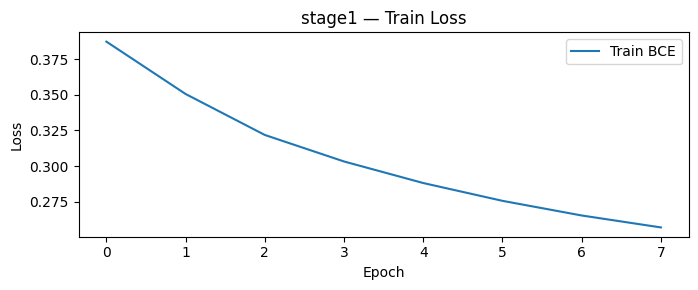

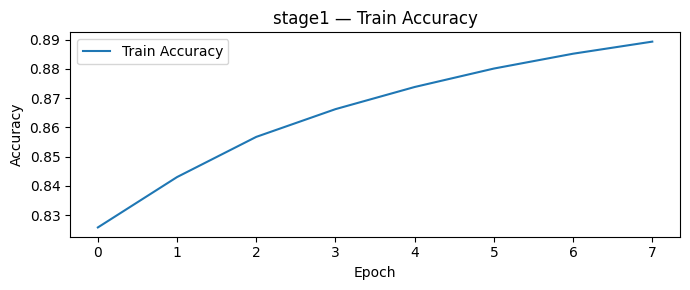

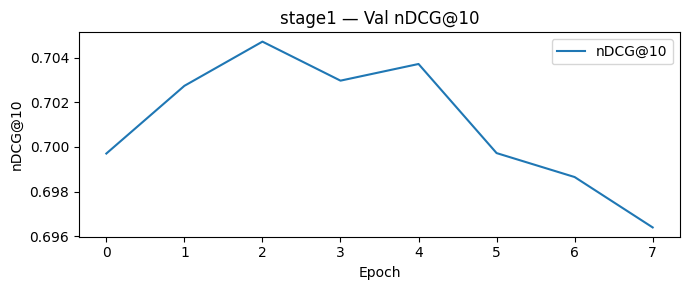

Loaded best weights from global_temporal_best_enhanced_ncf_stage1.pt


In [ ]:
model_s1 = FeatureEnhancedNCF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=32,
    static_emb_dim=0 if item_sbert_matrix is None else item_sbert_matrix.shape[1],
    dropout=0.5,
).to(DEVICE)

print("Training Stage 1...")
model_s1 = train_stage(
    model=model_s1,
    train_loader=train_loader_s1,
    val_eval_users=val_eval_users,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_books=top_1000_books,
    stage_name="stage1",
    item_sbert_matrix=item_sbert_matrix,
    num_epochs=10,
    patience=5,
    lr=0.001,
    monitor_metric=f"nDCG@{K}",
    eval_neg_samples=99,
)

In [ ]:
torch.save(
    model_s1.state_dict(),
    DATA_DIR + "global_temporal_best_enhanced_ncf_stage1.pt"
)

## Stage 1 Test Segment Analysis

After final test evaluation, Stage 1 performance is further analysed across user activity segments defined by the number of training interactions per user.

Two segmentations are used:
- **2-way split:** Non-sparse (`>= 5`) vs Sparse (`< 5`)
- **3-way split:** Low (`1–5`), Medium (`6–38`), and High (`39+`)

All segment-level results are computed on the sampled warm-start test users using the same ranking protocol as the main test evaluation, with **999 negatives per user**.

In [ ]:
stage1_test_results = evaluate_stage_lookup(
    model=model_s1,
    eval_users=test_eval_users,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_books=top_1000_books,
    stage_name="stage1_test",
    item_sbert_matrix=item_sbert_matrix,
    eval_neg_samples=999,
)

print(stage1_test_results)

Evaluating stage1_test:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_test — Results (K=10, 5,000 users)
HR@10  : 0.6292
MRR@10 : 0.5663
MAP@10 : 0.5663
nDCG@10: 0.5809
{'HR@10': 0.6292, 'MRR@10': np.float64(0.5662634920634919), 'MAP@10': np.float64(0.5662634920634919), 'nDCG@10': np.float64(0.5808748911732646)}


In [ ]:
# =========================================================
# 2-way user segmentation by TRAIN interaction count for Stage 1 test evaluation
# =========================================================
user_train_counts = train_df.groupby("user_id").size()

nonsparse_users = set(user_train_counts[user_train_counts >= 5].index)
sparse_users = set(user_train_counts[user_train_counts < 5].index)

print(f"Non-sparse users (>=5 train interactions): {len(nonsparse_users):,}")
print(f"Sparse users     (<5 train interactions): {len(sparse_users):,}")

segment_defs = [
    ("Non-sparse (>=5)", nonsparse_users),
    ("Sparse (<5)", sparse_users),
    ("All", None),
]

stage1_segment_results = {}

for seg_name, seg_set in segment_defs:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage1_segment_results[seg_name] = None
        continue

    seg_results = evaluate_stage_lookup(
        model=model_s1,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage1_test_{seg_name}",
        item_sbert_matrix=item_sbert_matrix,
        eval_neg_samples=999,
    )

    stage1_segment_results[seg_name] = seg_results

print("\nStage 1 segmented test results:")
print(stage1_segment_results)

Non-sparse users (>=5 train interactions): 214,060
Sparse users     (<5 train interactions): 196,680

Non-sparse (>=5): 3,698 eval users


Evaluating stage1_test_Non-sparse (>=5):   0%|          | 0/3698 [00:00<?, ?it/s]


stage1_test_Non-sparse (>=5) — Results (K=10, 3,698 users)
HR@10  : 0.6387
MRR@10 : 0.5847
MAP@10 : 0.5847
nDCG@10: 0.5973

Sparse (<5): 1,302 eval users


Evaluating stage1_test_Sparse (<5):   0%|          | 0/1302 [00:00<?, ?it/s]


stage1_test_Sparse (<5) — Results (K=10, 1,302 users)
HR@10  : 0.6022
MRR@10 : 0.5138
MAP@10 : 0.5138
nDCG@10: 0.5342

All: 5,000 eval users


Evaluating stage1_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_test_All — Results (K=10, 5,000 users)
HR@10  : 0.6292
MRR@10 : 0.5663
MAP@10 : 0.5663
nDCG@10: 0.5809

Stage 1 segmented test results:
{'Non-sparse (>=5)': {'HR@10': 0.6387236343969713, 'MRR@10': np.float64(0.584723724535785), 'MAP@10': np.float64(0.584723724535785), 'nDCG@10': np.float64(0.5972939674353219)}, 'Sparse (<5)': {'HR@10': 0.6021505376344086, 'MRR@10': np.float64(0.5138318947650743), 'MAP@10': np.float64(0.5138318947650743), 'nDCG@10': np.float64(0.5342406791785778)}, 'All': {'HR@10': 0.6292, 'MRR@10': np.float64(0.5662634920634919), 'MAP@10': np.float64(0.5662634920634919), 'nDCG@10': np.float64(0.5808748911732646)}}


In [ ]:
# =========================================================
# 3-way user segmentation by TRAIN interaction count for Stage 1 test evaluation
# =========================================================

def activity_bucket_3way(n):
    if n <= 5:
        return "Low (1-5)"
    elif n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

user_train_counts = train_df.groupby("user_id").size()

low_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Low (1-5)"].index)
medium_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Medium (6-38)"].index)
high_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "High (39+)"].index)

print(f"Low users    (1-5)   : {len(low_users):,}")
print(f"Medium users (6-38)  : {len(medium_users):,}")
print(f"High users   (39+)   : {len(high_users):,}")

segment_defs_3way = [
    ("Low (1-5)", low_users),
    ("Medium (6-38)", medium_users),
    ("High (39+)", high_users),
    ("All", None),
]

stage1_segment_results_3way = {}

for seg_name, seg_set in segment_defs_3way:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage1_segment_results_3way[seg_name] = None
        continue

    seg_results = evaluate_stage_lookup(
        model=model_s1,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage1_test_{seg_name}",
        item_sbert_matrix=item_sbert_matrix,
        eval_neg_samples=999,
    )

    stage1_segment_results_3way[seg_name] = seg_results

print("\nStage 1 3-way segmented test results:")
print(stage1_segment_results_3way)

Low users    (1-5)   : 218,284
Medium users (6-38)  : 153,375
High users   (39+)   : 39,081

Low (1-5): 1,517 eval users


Evaluating stage1_test_Low (1-5):   0%|          | 0/1517 [00:00<?, ?it/s]


stage1_test_Low (1-5) — Results (K=10, 1,517 users)
HR@10  : 0.6051
MRR@10 : 0.5205
MAP@10 : 0.5205
nDCG@10: 0.5401

Medium (6-38): 2,203 eval users


Evaluating stage1_test_Medium (6-38):   0%|          | 0/2203 [00:00<?, ?it/s]


stage1_test_Medium (6-38) — Results (K=10, 2,203 users)
HR@10  : 0.6087
MRR@10 : 0.5436
MAP@10 : 0.5436
nDCG@10: 0.5588

High (39+): 1,280 eval users


Evaluating stage1_test_High (39+):   0%|          | 0/1280 [00:00<?, ?it/s]


stage1_test_High (39+) — Results (K=10, 1,280 users)
HR@10  : 0.6930
MRR@10 : 0.6595
MAP@10 : 0.6595
nDCG@10: 0.6672

All: 5,000 eval users


Evaluating stage1_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage1_test_All — Results (K=10, 5,000 users)
HR@10  : 0.6292
MRR@10 : 0.5663
MAP@10 : 0.5663
nDCG@10: 0.5809

Stage 1 3-way segmented test results:
{'Low (1-5)': {'HR@10': 0.6051417270929466, 'MRR@10': np.float64(0.5205203461301022), 'MAP@10': np.float64(0.5205203461301022), 'nDCG@10': np.float64(0.540106190074457)}, 'Medium (6-38)': {'HR@10': 0.6087153881071267, 'MRR@10': np.float64(0.543618730591041), 'MAP@10': np.float64(0.543618730591041), 'nDCG@10': np.float64(0.5587822136625448)}, 'High (39+)': {'HR@10': 0.69296875, 'MRR@10': np.float64(0.6594500248015874), 'MAP@10': np.float64(0.6594500248015874), 'nDCG@10': np.float64(0.6672157412693667)}, 'All': {'HR@10': 0.6292, 'MRR@10': np.float64(0.5662634920634919), 'MAP@10': np.float64(0.5662634920634919), 'nDCG@10': np.float64(0.5808748911732646)}}


# Stage 2 — + Structured Item Metadata + Item Temporal Popularity

Adds:
- Structured metadata: `num_pages`, `publication_year`, `format_collapsed`, `is_ebook`, `language_code_collapsed`, `main_author_id`
- Item temporal popularity: `book_interactions_count_before_t`, `days_since_book_last_interaction`, `author_interactions_count_before_t`

Train Stage 2

Training Stage 2...


[stage2] Epoch 01:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage2_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_val — Results (K=10, 5,000 users)
HR@10  : 0.7992
MRR@10 : 0.6727
MAP@10 : 0.6727
nDCG@10: 0.7030
[stage2] Epoch 01  TrainLoss: 0.3814  TrainAcc: 0.8288  Val HR@10: 0.7992  Val MAP@10: 0.6727  Val nDCG@10: 0.7030  Val Users: 5,000
    ✓ Saved best model (nDCG@10: 0.7030)


[stage2] Epoch 02:   0%|          | 0/28436 [00:00<?, ?it/s]

...

Evaluating stage2_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_val — Results (K=10, 5,000 users)
HR@10  : 0.8044
MRR@10 : 0.6700
MAP@10 : 0.6700
nDCG@10: 0.7020
[stage2] Epoch 05  TrainLoss: 0.2781  TrainAcc: 0.8794  Val HR@10: 0.8044  Val MAP@10: 0.6700  Val nDCG@10: 0.7020  Val Users: 5,000


[stage2] Epoch 06:   0%|          | 0/28436 [00:00<?, ?it/s]

Evaluating stage2_val:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_val — Results (K=10, 5,000 users)
HR@10  : 0.8050
MRR@10 : 0.6687
MAP@10 : 0.6687
nDCG@10: 0.7011
[stage2] Epoch 06  TrainLoss: 0.2651  TrainAcc: 0.8858  Val HR@10: 0.8050  Val MAP@10: 0.6687  Val nDCG@10: 0.7011  Val Users: 5,000
Early stopping at epoch 6.


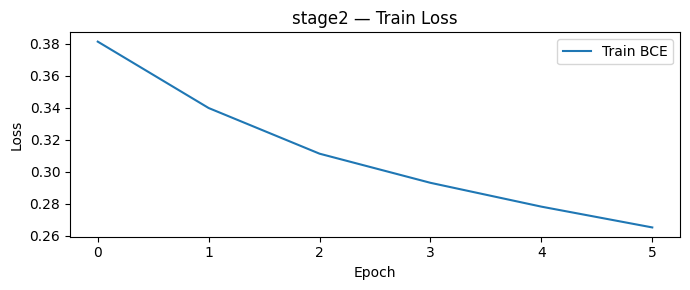

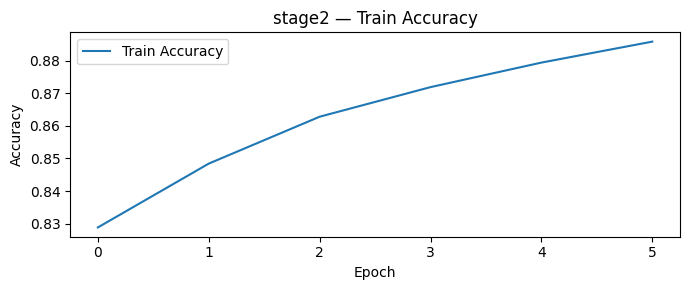

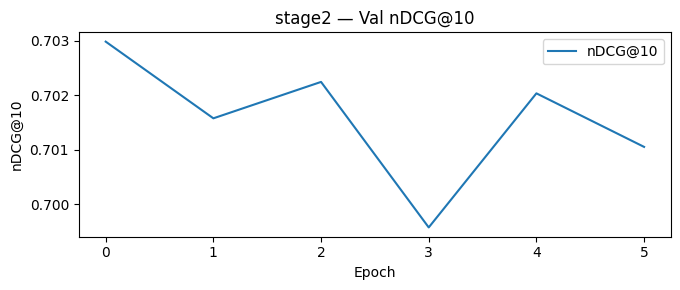

Loaded best weights from global_temporal_best_enhanced_ncf_stage2.pt


In [ ]:
model_s2 = FeatureEnhancedNCF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=32,
    num_formats=num_formats,
    num_langs=num_langs,
    num_authors=num_authors,
    num_numerical=0 if item_num_matrix is None else item_num_matrix.shape[1],
    static_emb_dim=0 if item_sbert_matrix is None else item_sbert_matrix.shape[1],
    dropout=0.5,
).to(DEVICE)

print("Training Stage 2...")
model_s2 = train_stage(
    model=model_s2,
    train_loader=train_loader_s2,
    val_eval_users=val_eval_users,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_books=top_1000_books,
    stage_name="stage2",
    item_cat_matrix=item_cat_matrix,
    item_num_matrix=item_num_matrix,
    item_sbert_matrix=item_sbert_matrix,
    num_epochs=10,
    patience=5,
    lr=0.001,
    monitor_metric=f"nDCG@{K}",
    eval_neg_samples=99,
)

In [ ]:
torch.save(
    model_s2.state_dict(),
    DATA_DIR + "global_temporal_best_enhanced_ncf_stage2.pt"
)

## Stage 2 Test Segment Analysis

After final test evaluation, Stage 1 performance is further analysed across user activity segments defined by the number of training interactions per user.

Two segmentations are used:
- **2-way split:** Non-sparse (`>= 5`) vs Sparse (`< 5`)
- **3-way split:** Low (`1–5`), Medium (`6–38`), and High (`39+`)

All segment-level results are computed on the sampled warm-start test users using the same ranking protocol as the main test evaluation, with **999 negatives per user**.

In [ ]:
stage2_test_results = evaluate_stage_lookup(
    model=model_s2,
    eval_users=test_eval_users,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_books=top_1000_books,
    stage_name="stage2_test",
    item_cat_matrix=item_cat_matrix,
    item_num_matrix=item_num_matrix,
    item_sbert_matrix=item_sbert_matrix,
    eval_neg_samples=999,
    seed=SEED,
)

print(stage2_test_results)

Evaluating stage2_test:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_test — Results (K=10, 5,000 users)
HR@10  : 0.6186
MRR@10 : 0.5554
MAP@10 : 0.5554
nDCG@10: 0.5700
{'HR@10': 0.6186, 'MRR@10': np.float64(0.5554069841269836), 'MAP@10': np.float64(0.5554069841269836), 'nDCG@10': np.float64(0.5699794730073311)}


In [ ]:
# =========================================================
# 2-way user segmentation by TRAIN interaction count for Stage 2 test evaluation
# =========================================================
user_train_counts = train_df.groupby("user_id").size()

nonsparse_users = set(user_train_counts[user_train_counts >= 5].index)
sparse_users = set(user_train_counts[user_train_counts < 5].index)

print(f"Non-sparse users (>=5 train interactions): {len(nonsparse_users):,}")
print(f"Sparse users     (<5 train interactions): {len(sparse_users):,}")

segment_defs = [
    ("Non-sparse (>=5)", nonsparse_users),
    ("Sparse (<5)", sparse_users),
    ("All", None),
]

stage2_segment_results = {}

for seg_name, seg_set in segment_defs:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage2_segment_results[seg_name] = None
        continue

    seg_results = evaluate_stage_lookup(
        model=model_s2,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage2_test_{seg_name}",
        item_cat_matrix=item_cat_matrix,
        item_num_matrix=item_num_matrix,
        item_sbert_matrix=item_sbert_matrix,
        eval_neg_samples=999,
    )

    stage2_segment_results[seg_name] = seg_results

print("\nStage 2 segmented test results:")
print(stage2_segment_results)

Non-sparse users (>=5 train interactions): 214,060
Sparse users     (<5 train interactions): 196,680

Non-sparse (>=5): 3,698 eval users


Evaluating stage2_test_Non-sparse (>=5):   0%|          | 0/3698 [00:00<?, ?it/s]


stage2_test_Non-sparse (>=5) — Results (K=10, 3,698 users)
HR@10  : 0.6260
MRR@10 : 0.5732
MAP@10 : 0.5732
nDCG@10: 0.5854

Sparse (<5): 1,302 eval users


Evaluating stage2_test_Sparse (<5):   0%|          | 0/1302 [00:00<?, ?it/s]


stage2_test_Sparse (<5) — Results (K=10, 1,302 users)
HR@10  : 0.5975
MRR@10 : 0.5048
MAP@10 : 0.5048
nDCG@10: 0.5261

All: 5,000 eval users


Evaluating stage2_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_test_All — Results (K=10, 5,000 users)
HR@10  : 0.6186
MRR@10 : 0.5554
MAP@10 : 0.5554
nDCG@10: 0.5700

Stage 2 segmented test results:
{'Non-sparse (>=5)': {'HR@10': 0.6260140616549487, 'MRR@10': np.float64(0.5732391811961847), 'MAP@10': np.float64(0.5732391811961847), 'nDCG@10': np.float64(0.5854406545171559)}, 'Sparse (<5)': {'HR@10': 0.5975422427035331, 'MRR@10': np.float64(0.5047591617292081), 'MAP@10': np.float64(0.5047591617292081), 'nDCG@10': np.float64(0.5260659175362667)}, 'All': {'HR@10': 0.6186, 'MRR@10': np.float64(0.5554069841269836), 'MAP@10': np.float64(0.5554069841269836), 'nDCG@10': np.float64(0.5699794730073311)}}


In [ ]:
# =========================================================
# 3-way user segmentation by TRAIN interaction count for Stage 2 test evaluation
# =========================================================

def activity_bucket_3way(n):
    if n <= 5:
        return "Low (1-5)"
    elif n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

user_train_counts = train_df.groupby("user_id").size()

low_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Low (1-5)"].index)
medium_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "Medium (6-38)"].index)
high_users = set(user_train_counts[user_train_counts.apply(activity_bucket_3way) == "High (39+)"].index)

print(f"Low users    (1-5)   : {len(low_users):,}")
print(f"Medium users (6-38)  : {len(medium_users):,}")
print(f"High users   (39+)   : {len(high_users):,}")

segment_defs_3way = [
    ("Low (1-5)", low_users),
    ("Medium (6-38)", medium_users),
    ("High (39+)", high_users),
    ("All", None),
]

stage2_segment_results_3way = {}

for seg_name, seg_set in segment_defs_3way:
    if seg_set is None:
        seg_eval_users = test_eval_users
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users if uid in seg_set]

    print(f"\n{seg_name}: {len(seg_eval_users):,} eval users")

    if len(seg_eval_users) == 0:
        stage2_segment_results_3way[seg_name] = None
        continue

    seg_results = evaluate_stage_lookup(
        model=model_s2,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_books=top_1000_books,
        stage_name=f"stage2_test_{seg_name}",
        item_cat_matrix=item_cat_matrix,
        item_num_matrix=item_num_matrix,
        item_sbert_matrix=item_sbert_matrix,
        eval_neg_samples=999,
    )

    stage2_segment_results_3way[seg_name] = seg_results

print("\nStage 2 3-way segmented test results:")
print(stage2_segment_results_3way)

Low users    (1-5)   : 218,284
Medium users (6-38)  : 153,375
High users   (39+)   : 39,081

Low (1-5): 1,517 eval users


Evaluating stage2_test_Low (1-5):   0%|          | 0/1517 [00:00<?, ?it/s]


stage2_test_Low (1-5) — Results (K=10, 1,517 users)
HR@10  : 0.6018
MRR@10 : 0.5128
MAP@10 : 0.5128
nDCG@10: 0.5333

Medium (6-38): 2,203 eval users


Evaluating stage2_test_Medium (6-38):   0%|          | 0/2203 [00:00<?, ?it/s]


stage2_test_Medium (6-38) — Results (K=10, 2,203 users)
HR@10  : 0.5928
MRR@10 : 0.5306
MAP@10 : 0.5306
nDCG@10: 0.5449

High (39+): 1,280 eval users


Evaluating stage2_test_High (39+):   0%|          | 0/1280 [00:00<?, ?it/s]


stage2_test_High (39+) — Results (K=10, 1,280 users)
HR@10  : 0.6828
MRR@10 : 0.6486
MAP@10 : 0.6486
nDCG@10: 0.6566

All: 5,000 eval users


Evaluating stage2_test_All:   0%|          | 0/5000 [00:00<?, ?it/s]


stage2_test_All — Results (K=10, 5,000 users)
HR@10  : 0.6186
MRR@10 : 0.5554
MAP@10 : 0.5554
nDCG@10: 0.5700

Stage 2 3-way segmented test results:
{'Low (1-5)': {'HR@10': 0.6018457481872116, 'MRR@10': np.float64(0.5128150798882508), 'MAP@10': np.float64(0.5128150798882508), 'nDCG@10': np.float64(0.5332880861040608)}, 'Medium (6-38)': {'HR@10': 0.5928279618701771, 'MRR@10': np.float64(0.5305964449632175), 'MAP@10': np.float64(0.5305964449632175), 'nDCG@10': np.float64(0.5449441084716176)}, 'High (39+)': {'HR@10': 0.6828125, 'MRR@10': np.float64(0.6485863095238097), 'MAP@10': np.float64(0.6485863095238097), 'nDCG@10': np.float64(0.6565527089483016)}, 'All': {'HR@10': 0.6186, 'MRR@10': np.float64(0.5554069841269836), 'MAP@10': np.float64(0.5554069841269836), 'nDCG@10': np.float64(0.5699794730073311)}}
